In [180]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
from scipy.optimize import curve_fit
lumapiFile = "C:\\Program Files\\Lumerical\\v261\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

In [181]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [182]:
intcApi = lumapi.INTERCONNECT()

In [183]:
#units

## Length
nm = 1e-9
um = 1e-6
## Power
mW = 1e-3
## Time
ns = 1e-9
## Frequency
GHz = 1e9
THz = 1e12
## Resistance
kOhms = 1e3

# constants
lambda0 = 1550*nm
f0 = c/lambda0

PIN_responsivity = 0.75 #A/W
time_window = 120*ns
W_in_dBm = 0
transimpedance = 0.5 * kOhms

def dBm(W):
    return 10*np.log10(W/(1*mW))

def W(dBm):
    return 1*mW*10**(dBm/10)

In [184]:
hybrid_file = "C:/Users/LucasGabriel/OneDrive/Documentos/Layouts_and_simulations/Lumerical/Laboratories/90_optical_hybrid/90_hybrid_S_params.dat"

## Constructing the circuit ##

In [185]:
intcApi.deleteall()

intcApi.set('time window', time_window)

intcApi.addelement('Optical N Port S-Parameter')
intcApi.set('name', '90 hybrid')
intcApi.set('load from file', 1)
intcApi.set('s parameters filename', hybrid_file)
intcApi.set('load from file', 0)
intcApi.set('x position', 0)
intcApi.set('y position', 0)

intcApi.addelement('CW Laser')
intcApi.set('name', 'LO')
intcApi.set('frequency', f0)
intcApi.set('power', W(W_in_dBm))
intcApi.set('x position', 0)
intcApi.set('y position', -200)
intcApi.rotateelement('LO')
intcApi.connect('LO', 'output', '90 hybrid', 'porta LO')

intcApi.addelement('CW Laser')
intcApi.set('name', 'Signal')
intcApi.set('frequency', f0)
intcApi.set('power', W(W_in_dBm))
intcApi.set('x position', 0)
intcApi.set('y position', 200)
for i in range(0,3,1):
    intcApi.rotateelement('Signal')
intcApi.connect('Signal', 'output', '90 hybrid', 'porta Sinal')

intcApi.addelement('PIN Photodetector')
intcApi.set('name', 'In detector')
intcApi.set('thermal noise', 0)
intcApi.set('responsivity', PIN_responsivity)
intcApi.set('x position', 200)
intcApi.set('y position', -50)
intcApi.connect('90 hybrid', 'porta In', 'In detector', 'input')

intcApi.addelement('PIN Photodetector')
intcApi.set('name', 'Ip detector')
intcApi.set('thermal noise', 0)
intcApi.set('responsivity', PIN_responsivity)
intcApi.set('x position', 200)
intcApi.set('y position', 50)
intcApi.connect('90 hybrid', 'porta Ip', 'Ip detector', 'input')

intcApi.addelement('PIN Photodetector')
intcApi.set('name', 'Qn detector')
intcApi.set('thermal noise', 0)
intcApi.set('responsivity', PIN_responsivity)
intcApi.set('x position', -200)
intcApi.set('y position', -50)
for i in range(0,2,1):
    intcApi.rotateelement('Qn detector')
intcApi.connect('90 hybrid', 'porta Qn', 'Qn detector', 'input')

intcApi.addelement('PIN Photodetector')
intcApi.set('name', 'Qp detector')
intcApi.set('thermal noise', 0)
intcApi.set('responsivity', PIN_responsivity)
intcApi.set('x position', -200)
intcApi.set('y position', 50)
for i in range(0,2,1):
    intcApi.rotateelement('Qp detector')
intcApi.connect('90 hybrid', 'porta Qp', 'Qp detector', 'input')

intcApi.addelement('Transimpedance Amplifier')
intcApi.set('name', 'In TIA')
intcApi.set('enable noise', 0)
intcApi.set('x position', 350)
intcApi.set('y position', -50)
intcApi.set('transimpedance', transimpedance)
intcApi.connect('In detector', 'output', 'In TIA', 'input')

intcApi.addelement('Transimpedance Amplifier')
intcApi.set('name', 'Ip TIA')
intcApi.set('enable noise', 0)
intcApi.set('x position', 350)
intcApi.set('y position', 50)
intcApi.set('transimpedance', transimpedance)
intcApi.connect('Ip detector', 'output', 'Ip TIA', 'input')

intcApi.addelement('Transimpedance Amplifier')
intcApi.set('name', 'Qn TIA')
intcApi.set('enable noise', 0)
intcApi.set('x position', -350)
intcApi.set('y position', -50)
for i in range(0,2,1):
    intcApi.rotateelement('Qn TIA')
intcApi.set('transimpedance', transimpedance)
intcApi.connect('Qn detector', 'output', 'Qn TIA', 'input')

intcApi.addelement('Transimpedance Amplifier')
intcApi.set('name', 'Qp TIA')
intcApi.set('enable noise', 0)
intcApi.set('x position', -350)
intcApi.set('y position', 50)
for i in range(0,2,1):
    intcApi.rotateelement('Qp TIA')
intcApi.set('transimpedance', transimpedance)
intcApi.connect('Qp detector', 'output', 'Qp TIA', 'input')

intcApi.addelement('Electrical Subtractor')
intcApi.set('name', 'I substractor')
intcApi.set('x position', 500)
intcApi.set('y position', 10)
intcApi.connect('In TIA', 'output', 'I substractor', 'input 1')
intcApi.connect('Ip TIA', 'output', 'I substractor', 'input 2')

intcApi.addelement('Electrical Subtractor')
intcApi.set('name', 'Q substractor')
intcApi.set('x position', -500)
intcApi.set('y position', 10)
for i in range(0,2,1):
    intcApi.rotateelement('Q substractor')
intcApi.connect('Qn TIA', 'output', 'Q substractor', 'input 1')
intcApi.connect('Qp TIA', 'output', 'Q substractor', 'input 2')

intcApi.addelement('Oscilloscope')
intcApi.set('name', 'I oscilloscope')
intcApi.set('x position', 800)
intcApi.set('y position', 10)
intcApi.connect('I substractor', 'output', 'I oscilloscope', 'input')

intcApi.addelement('Oscilloscope')
intcApi.set('name', 'Q oscilloscope')
intcApi.set('x position', -800)
intcApi.set('y position', 10)
for i in range(0,2,1):
    intcApi.rotateelement('Q oscilloscope')
intcApi.connect('Q substractor', 'output', 'Q oscilloscope', 'input')

intcApi.save('90_hybrid_INTERCONNECT')
intcApi.exportimage('circuito_teste.png')

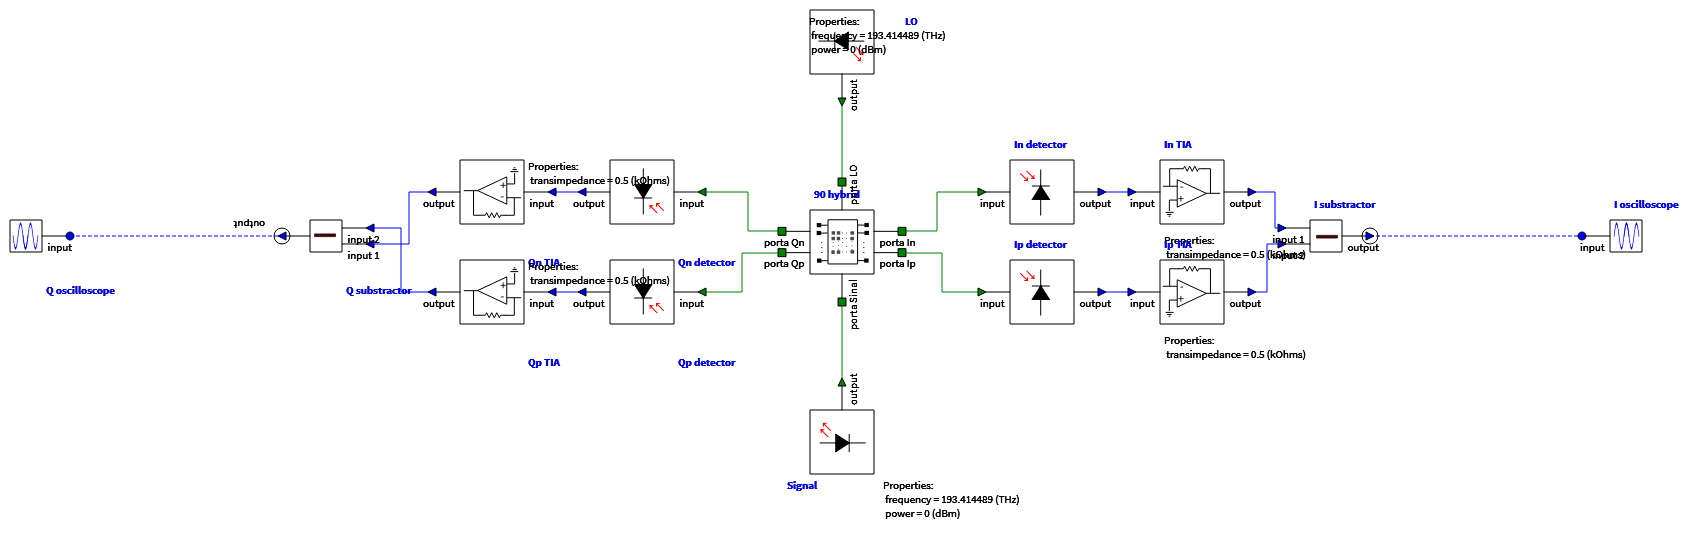

In [186]:
image_file_png = "C:/Users/LucasGabriel/OneDrive/Documentos/Layouts_and_simulations/Lumerical/Laboratories/90_optical_hybrid/circuito_teste.png"
#image_file_svg = "C:/Users/LucasGabriel/OneDrive/Documentos/Layouts_and_simulations/Lumerical/Laboratories/90_optical_hybrid/circuito_teste.svg"
from IPython.display import Image, display

display(Image(filename=image_file_png))

## Obtaining the parameters of the 90° hybrid ##

In [187]:
delta_f = 10*GHz
intcApi.setnamed('LO', 'frequency', f0+delta_f)

In [188]:
intcApi.run()

In [189]:
t = intcApi.getresult("I oscilloscope", "signal")['time']/ns
output_I = intcApi.getresult("I oscilloscope", "signal")['amplitude (a.u.)']
output_Q = intcApi.getresult("Q oscilloscope", "signal")['amplitude (a.u.)']

mask = (t >= 0.98*time_window/ns) & (t <= (0.98*time_window+3/delta_f)/ns)
t_window = t[mask]
output_I_window = (output_I.reshape(-1,1))[mask]
output_Q_window = (output_Q.reshape(-1,1))[mask]

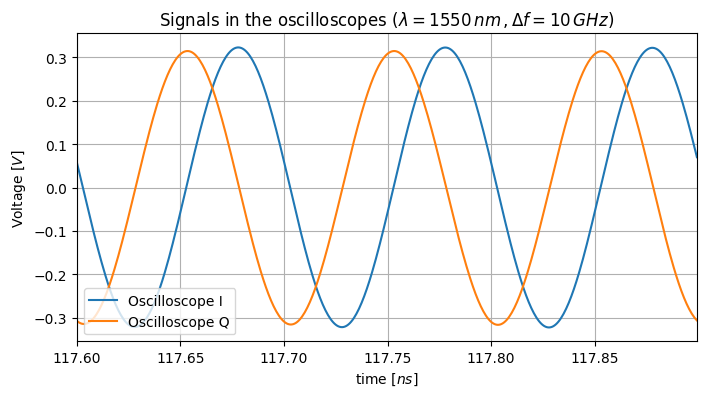

In [232]:
plt.plot(t_window, output_I_window, label = 'Oscilloscope I')
plt.plot(t_window, output_Q_window, label = 'Oscilloscope Q')
plt.grid(True)
plt.xlabel('time [$ns$]')
plt.ylabel('Voltage [$V$]')
plt.legend(loc = 'lower left')
plt.xlim([t_window[0], t_window[-1]])
plt.title(r'Signals in the oscilloscopes ($\lambda = 1550\,nm\,,\Delta f = 10\,GHz$)')
plt.show()

### Phase difference and Phase error ###

In [191]:
from IPython.display import clear_output

output_I_matrix = []
output_Q_matrix = []
t_matrix = []

number_of_frequencies = 12
wavelength_step = 2.5 #nm

delta_f_array = np.linspace(1,12,number_of_frequencies)*GHz
lambda_array = np.arange(1530, 1565 + wavelength_step, wavelength_step)*nm

for lambda_ in lambda_array:
    f = c/lambda_
    intcApi.switchtodesign()
    intcApi.setnamed('Signal', 'frequency', f)

    output_I_array = []
    output_Q_array = []
    t_array = []

    for df in delta_f_array:
        clear_output(wait=True)
        print('for \u03BB = %.1f nm and \u0394f = %.1f GHz' %(lambda_/nm, df/GHz))
        intcApi.switchtodesign()
        intcApi.setnamed('LO', 'frequency', f+df)
        intcApi.run()

        t = intcApi.getresult("I oscilloscope", "signal")['time']/ns
        output_I = intcApi.getresult("I oscilloscope", "signal")['amplitude (a.u.)']
        output_Q = intcApi.getresult("Q oscilloscope", "signal")['amplitude (a.u.)']

        mask = (t >= 0.98*time_window/ns) & (t <= (0.98*time_window+3/df)/ns)
        t = t[mask]
        output_I= (output_I.reshape(-1,1))[mask]
        output_Q= (output_Q.reshape(-1,1))[mask]

        output_I_array.append(output_I)
        output_Q_array.append(output_Q)
        t_array.append(t)
    
    output_I_matrix.append(output_I_array)
    output_Q_matrix.append(output_Q_array)
    t_matrix.append(t_array)

for λ = 1565.0 nm and Δf = 12.0 GHz


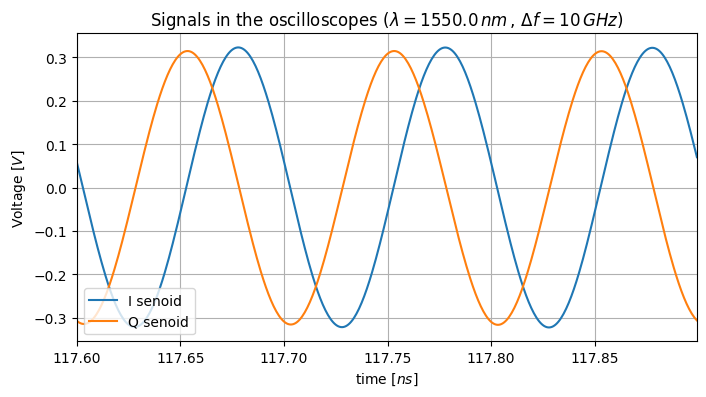

In [233]:
n = 8
k = 9

plt.plot(t_matrix[n][k], output_I_matrix[n][k], label = 'I senoid')
plt.plot(t_matrix[n][k], output_Q_matrix[n][k], label = 'Q senoid')
plt.grid(True)
plt.legend(loc = 'lower left')
plt.xlabel('time [$ns$]')
plt.ylabel('Voltage [$V$]')
plt.xlim([t_matrix[n][k][0], t_matrix[n][k][-1]])
plt.title(r'Signals in the oscilloscopes ($\lambda = %.1f\,nm\,,\,\Delta f = %d\,GHz$)' %(lambda_array[n]/nm, delta_f_array[k]/GHz))
plt.show()

In [193]:
phi_dif_matrix = []

for n in range(0, len(lambda_array), 1):
    phi_dif_array = []
    for k in range(0, len(delta_f_array), 1):
        df = delta_f_array[k]
        x1 = np.cos(2*np.pi*df*t_matrix[n][k]*ns)
        x2 = np.sin(2*np.pi*df*t_matrix[n][k]*ns)
        x3 = np.ones_like(t_matrix[n][k])

        X = np.column_stack([x1,x2,x3])

        C, residues, rank, s = np.linalg.lstsq(X, output_I_matrix[n][k], rcond=None)
        C1, C2, C3 = C
        D, residues, rank, s = np.linalg.lstsq(X, output_Q_matrix[n][k], rcond=None)
        D1, D2, D3 = D

        phi_I = np.arctan2(-C2,C1)
        phi_Q = np.arctan2(-D2,D1)

        phi_dif = np.abs(phi_I - phi_Q)*180/np.pi
        if phi_dif > 180:
            phi_dif = 360 - phi_dif

        phi_dif_array.append(phi_dif)
    phi_dif_matrix.append(phi_dif_array)

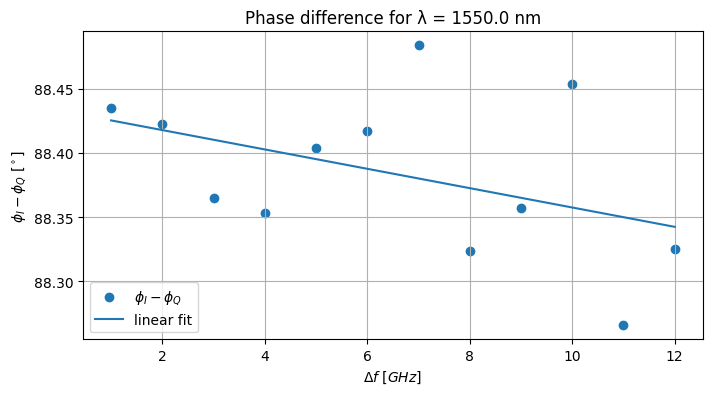

Phase difference at Δf = 0: 88.43°.
Phase error: 1.57°


In [234]:
n = 8

X = np.column_stack([delta_f_array/GHz, np.ones_like(delta_f_array)])

coeficients, residues, rank, s = np.linalg.lstsq(X, phi_dif_matrix[n], rcond=None)
a, b = coeficients

plt.scatter(delta_f_array/GHz, phi_dif_matrix[n], label = r'$\phi_I - \phi_Q$')
plt.plot(delta_f_array/GHz, a*delta_f_array/GHz + b, label = 'linear fit')
plt.grid(True)
plt.legend(loc = 'lower left')
plt.xlabel(r'$\Delta f$ [$GHz$]')
plt.ylabel(r'$\phi_{I} - \phi_{Q}$ [$^\circ$]')
plt.title('Phase difference for \u03BB = %.1f nm' %(lambda_array[n]/nm))
plt.show()

print('Phase difference at \u0394f = 0: %.2f\u00B0.\nPhase error: %.2f\u00B0' %(b, 90-b))

In [195]:
phase_error_array = []

for n in range(0, len(lambda_array), 1):
    phi_dif_array = phi_dif_matrix[n]

    X = np.column_stack([delta_f_array/GHz, np.ones_like(delta_f_array)])

    coeficients, residues, rank, s = np.linalg.lstsq(X, phi_dif_array, rcond=None)
    a, b = coeficients

    phase_error = 90 - b
    phase_error_array.append(phase_error)

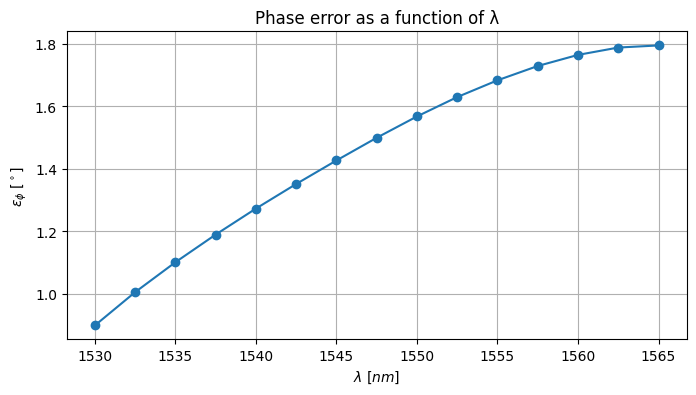

In [231]:
plt.plot(lambda_array/nm, phase_error_array, 'o-')
plt.grid(True)
plt.title('Phase error as a function of \u03BB')
plt.xlabel(r'$\lambda$ [$nm$]')
plt.ylabel(r'$\epsilon_\phi$ [$^\circ$]')
#plt.ylim([np.min(phase_error_array), np.max(phase_error_array)])
plt.show()

In [197]:
intcApi.close()